# Student success model comparison

This notebook fits and compares three actual classifiers on the synthetic student-success data:

1. A majority-class baseline, which establishes the performance floor.
2. Regularized logistic regression, which is transparent and easy to audit.
3. A random forest, which can capture nonlinear relationships.

The models are examples for research and teaching. They must not be used to make automated decisions about real students.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.evaluation import classification_metrics, demographic_parity_difference, subgroup_metrics
RANDOM_STATE = 42
TARGET = 'persisted_next_term'
SENSITIVE_COLUMNS = ['first_generation', 'financial_aid', 'online_student', 'age_band']
data = pd.read_csv(ROOT / 'data/synthetic/student_success.csv')
features = data.drop(columns=[TARGET, 'student_id'])
X_train, X_test, y_train, y_test = train_test_split(
    features, data[TARGET], test_size=0.25, random_state=RANDOM_STATE, stratify=data[TARGET]
)
categorical = ['age_band']
numeric = [column for column in features.columns if column not in categorical]
preprocessing = ColumnTransformer([
    ('numeric', StandardScaler(), numeric),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical),
])
print(f'Train rows: {len(X_train):,}; test rows: {len(X_test):,}')
print(f'Observed persistence rate: {data[TARGET].mean():.1%}')

Train rows: 375; test rows: 125
Observed persistence rate: 41.8%


## Fit and compare models

In [2]:
models = {
    'majority baseline': Pipeline([
        ('preprocessing', preprocessing),
        ('classifier', DummyClassifier(strategy='prior')),
    ]),
    'logistic regression': Pipeline([
        ('preprocessing', preprocessing),
        ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'random forest': Pipeline([
        ('preprocessing', preprocessing),
        ('classifier', RandomForestClassifier(
            n_estimators=200, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1
        )),
    ]),
}

fitted_models = {}
predictions = {}
comparison = []
for name, model in models.items():
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_test)[:, 1]
    prediction = (probability >= 0.5).astype(int)
    fitted_models[name] = model
    predictions[name] = (prediction, probability)
    comparison.append({'model': name, **classification_metrics(y_test, prediction, probability)})

comparison = pd.DataFrame(comparison).set_index('model').sort_values('roc_auc', ascending=False)
display(comparison.round(3))

,roc_auc,balanced_accuracy,accuracy,precision,recall,f1,brier_score
model,,,,,,,
logistic regression,0.697,0.695,0.712,0.674,0.596,0.633,0.219
random forest,0.610,0.540,0.560,0.468,0.423,0.444,0.245
majority baseline,0.500,0.500,0.584,0.000,0.000,0.000,0.243


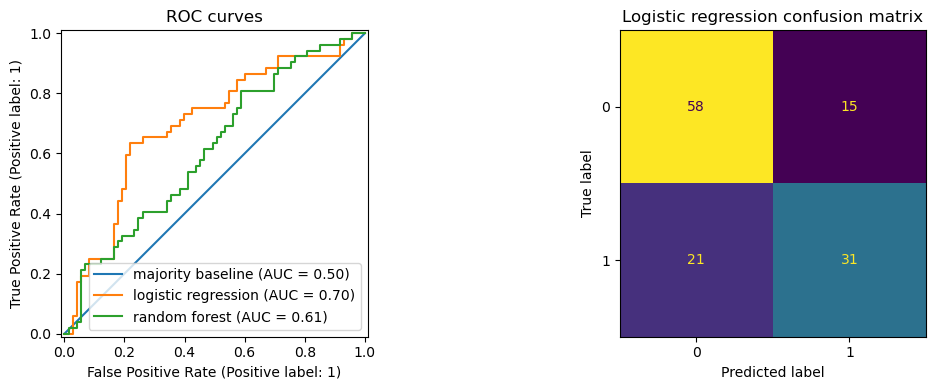

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, (prediction, probability) in predictions.items():
    RocCurveDisplay.from_predictions(y_test, probability, name=name, ax=axes[0])
axes[0].set_title('ROC curves')
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions['logistic regression'][0], ax=axes[1], colorbar=False
)
axes[1].set_title('Logistic regression confusion matrix')
plt.tight_layout()
plt.show()

## Interpret the transparent model

The logistic model's coefficients show direction and relative strength after numeric standardization. Coefficients are associations, not causal effects.

,coefficient
numeric__first_generation,-0.451770
numeric__online_student,-0.274169
numeric__financial_aid,-0.132080
categorical__age_band_18-20,-0.057046
categorical__age_band_25+,0.026306
categorical__age_band_21-24,0.029895
numeric__credits_attempted,0.130325
numeric__advising_contacts,0.140565
numeric__attendance_rate,0.498121
numeric__prior_gpa,0.761158


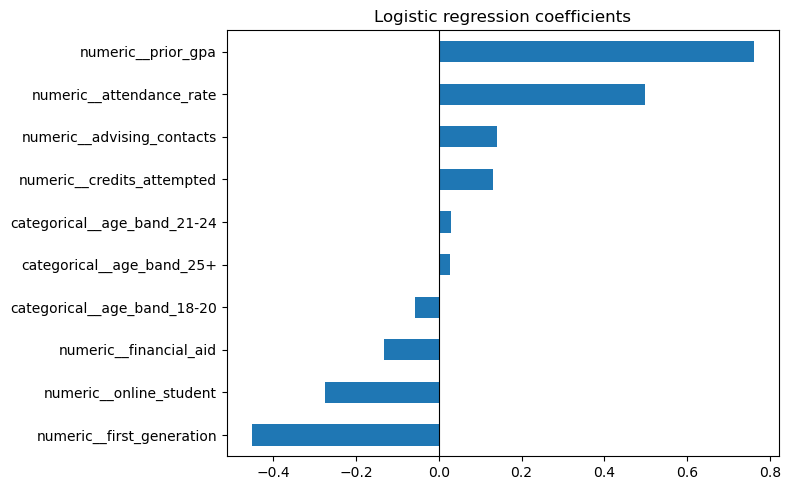

In [4]:
logistic = fitted_models['logistic regression']
transformed_names = logistic.named_steps['preprocessing'].get_feature_names_out()
coefficients = pd.Series(
    logistic.named_steps['classifier'].coef_[0], index=transformed_names
).sort_values()
display(coefficients.to_frame('coefficient'))
coefficients.plot.barh(figsize=(8, 5), title='Logistic regression coefficients')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Fairness diagnostics

The diagnostics below use the logistic regression model and show observed outcomes, predicted-positive rates, and recall by subgroup. A demographic-parity difference is descriptive only; it is not a fairness verdict.

In [5]:
best_prediction, best_probability = predictions['logistic regression']
test_results = X_test.copy()
test_results[TARGET] = y_test
test_results['prediction'] = best_prediction
test_results['probability'] = best_probability
for column in SENSITIVE_COLUMNS:
    table = subgroup_metrics(test_results, column, TARGET, 'prediction')
    print(f'{column}: demographic parity difference = {demographic_parity_difference(table):.3f}')
    display(table)


first_generation: demographic parity difference = 0.401


,group,n,positive_rate,predicted_positive_rate,recall,false_positive_rate
0,0,80,0.462500,0.512500,0.729730,0.325581
1,1,45,0.333333,0.111111,0.266667,0.033333


financial_aid: demographic parity difference = 0.195


,group,n,positive_rate,predicted_positive_rate,recall,false_positive_rate
0,0,65,0.446154,0.461538,0.655172,0.305556
1,1,60,0.383333,0.266667,0.521739,0.108108


online_student: demographic parity difference = 0.206


,group,n,positive_rate,predicted_positive_rate,recall,false_positive_rate
0,0,82,0.463415,0.439024,0.631579,0.272727
1,1,43,0.325581,0.232558,0.500000,0.103448


age_band: demographic parity difference = 0.079


,group,n,positive_rate,predicted_positive_rate,recall,false_positive_rate
0,18-20,86,0.372093,0.372093,0.656250,0.203704
1,21-24,29,0.620690,0.379310,0.555556,0.090909
2,25+,10,0.200000,0.300000,0.000000,0.375000
